# ISM — appendix exhibits (Figures A1-A8, Tables A1-A6)

Companion to `ISM_replication.ipynb` and `ISM_expand.ipynb`. Reproduces the
paper's online-appendix figures and tables, built on the tested modules in
`src/ism` (`appendix`, `engine`, `forecasting`, `oos_lasso`, `local_projection`).
No install needed — we add `src/` to the path.

Some cells are compute-heavy (multiple full-history ISM variants, the AR(3) LASSO,
the IRF robustness grid); these are flagged.

## Setup — build the ISM variants once

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
REPO_ROOT = Path.cwd().parent if Path.cwd().name=="notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT/"src"))
try:
    from dotenv import load_dotenv; load_dotenv(REPO_ROOT/".env")
except Exception: pass

from ism.engine import (ISMConfig, residual_panel, momentum_signals,
                        expenditure_weighted_shares, ism_index, compute_ism)
from ism import appendix as ap
from ism import forecasting, oos_lasso
from ism.local_projection import irf_price_to_ism
from ism.datasources import FredClient
from ism import controls as controls_mod
from ism.transforms import monthly_inflation, yoy_inflation
OUT = REPO_ROOT/"outputs"; OUT.mkdir(exist_ok=True)

BEA = REPO_ROOT/"data"/"raw"/"bea"
def _nk(c): c=str(c); return c[1:] if c[:2] in ("IA","LA") else c[:-1]
def _bea(t):
    d=json.loads((BEA/f"{t}_M.json").read_text()); df=pd.DataFrame(d["BEAAPI"]["Results"]["Data"])
    df["DataValue"]=pd.to_numeric(df["DataValue"].astype(str).str.replace(",","",regex=False),errors="coerce")
    df["date"]=pd.to_datetime(df["TimePeriod"].astype(str).str.replace("M","-")+"-01",errors="coerce")
    df["key"]=df["SeriesCode"].map(_nk); return df

cats = pd.read_csv(REPO_ROOT/"config"/"pce_categories.csv")
price, nominal = _bea("U20404"), _bea("U20405")
pw = price.pivot_table(index="date",columns="key",values="DataValue",aggfunc="first").sort_index()
nw = nominal.pivot_table(index="date",columns="key",values="DataValue",aggfunc="first").sort_index()
keys = [k for k in cats["key"].astype(str) if k in pw.columns and k in nw.columns]
infl = monthly_inflation(pw[keys])
weights = nw[keys].div(nw[keys].sum(axis=1).replace(0,np.nan),axis=0)
common = infl.index.intersection(weights.index); infl, weights = infl.loc[common], weights.loc[common]

# Residual panels per AR order (expensive: computed once); k variants are cheap.
resid = {p: residual_panel(infl, ISMConfig(ar_order=p)) for p in (1,3,12)}
def ism_variant(ar=1, k=3):
    mp, mn = momentum_signals(resid[ar], ISMConfig(run_length=k))
    sp, sn = expenditure_weighted_shares(mp, mn, weights)
    return ism_index(sp, sn), sp, sn

ism_b, sp_b, sn_b = ism_variant(1,3)   # baseline AR(1), k=3
fred = FredClient()
pcepi = fred.series("PCEPI"); pcepi.index = pd.to_datetime(pcepi.index).to_period("M").to_timestamp()
agg_infl = monthly_inflation(pcepi).rename("agg_infl")
pce_yoy = yoy_inflation(pcepi).rename("pce_yoy")
controls = controls_mod.build_controls(fred)
print("variants ready; baseline ISM months:", ism_b.dropna().shape[0])

[controls] Barnichon HWI not found -> V/U from 2000 only: Barnichon HWI not found at C:\Users\tbretagne\Dropbox\GitHub\ISMI_Shapiro\ISMI\data\raw\external\barnichon_hwi.csv. Download the 'Composite HWI' file from https://sites.google.com/site/regisbarnichon/data and save it there as two columns (date, index).
variants ready; baseline ISM months: 808


## Figure A1a — rolling rho-hat and alpha-hat (headline PCE)

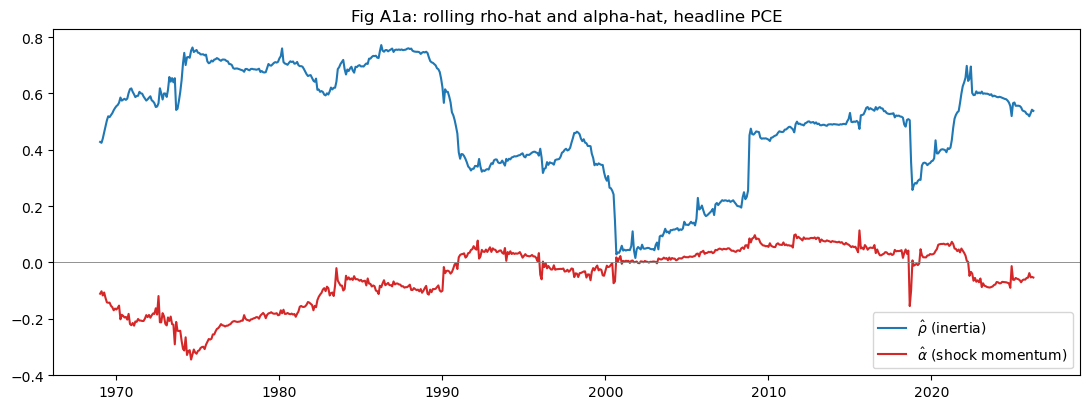

In [2]:
ra = ap.rolling_rho_alpha(agg_infl, window=120)
fig, ax = plt.subplots(figsize=(11,4.2))
ax.plot(ra.index, ra["rho_hat"], label=r"$\hat\rho$ (inertia)", color="tab:blue")
ax.plot(ra.index, ra["alpha_hat"], label=r"$\hat\alpha$ (shock momentum)", color="tab:red")
ax.axhline(0, color="grey", lw=.6); ax.legend(); ax.set_title("Fig A1a: rolling rho-hat and alpha-hat, headline PCE")
fig.tight_layout(); fig.savefig(OUT/"figA1a_rho_alpha.png", dpi=130); plt.show()

## Figure A1b — distribution of category rho-hat across categories

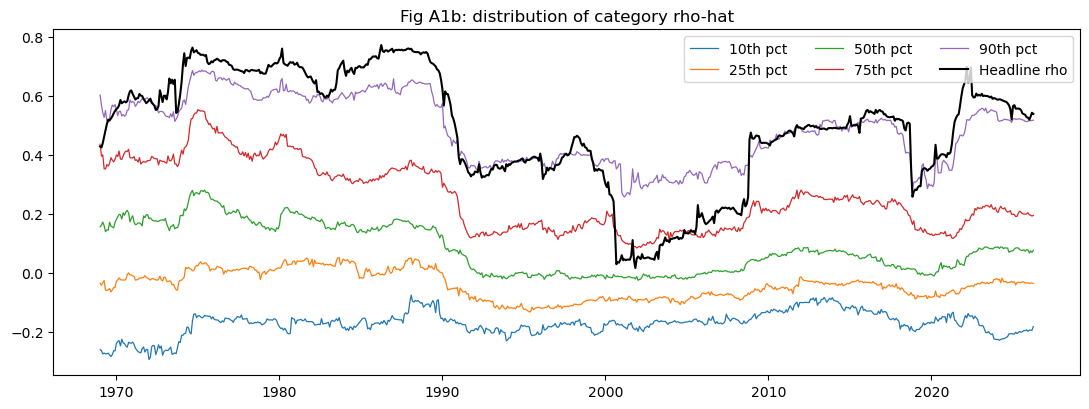

In [3]:
# heavy-ish: per-category rolling rho-hat
rho_p = ap.rho_panel(infl, ISMConfig(ar_order=1))
pct = rho_p.quantile([0.1,0.25,0.5,0.75,0.9], axis=1).T
ra_head = ap.rolling_rho_alpha(agg_infl, window=120)["rho_hat"]
fig, ax = plt.subplots(figsize=(11,4.2))
for q in pct.columns:
    ax.plot(pct.index, pct[q], lw=.9, label=f"{int(q*100)}th pct")
ax.plot(ra_head.index, ra_head, color="black", lw=1.5, label="Headline rho")
ax.legend(ncol=3); ax.set_title("Fig A1b: distribution of category rho-hat"); fig.tight_layout()
fig.savefig(OUT/"figA1b_rho_dist.png", dpi=130); plt.show()

## Figure A2 — empirical distribution of consecutive same-signed residuals

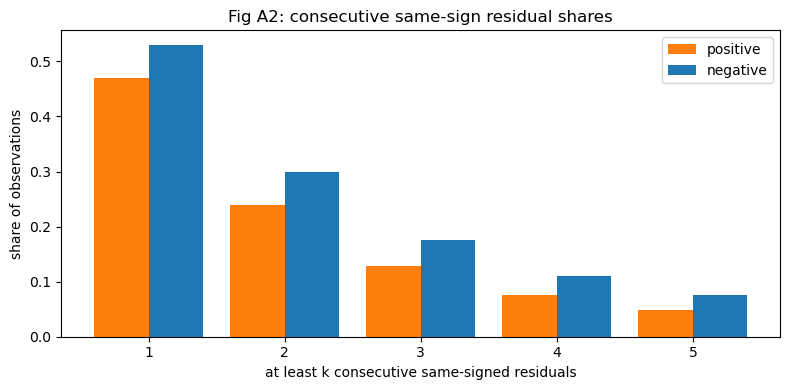

,k,positive_share,negative_share
0,1,0.469660,0.529833
1,2,0.238934,0.299252
2,3,0.128856,0.175384
3,4,0.076462,0.111024
4,5,0.049365,0.074954


In [4]:
sh = ap.consecutive_run_shares(resid[1], kmax=5)
fig, ax = plt.subplots(figsize=(8,4))
x = sh["k"]; w=.4
ax.bar(x-w/2, sh["positive_share"], width=w, label="positive", color="tab:orange")
ax.bar(x+w/2, sh["negative_share"], width=w, label="negative", color="tab:blue")
ax.set_xlabel("at least k consecutive same-signed residuals"); ax.set_ylabel("share of observations")
ax.set_title("Fig A2: consecutive same-sign residual shares"); ax.legend()
fig.tight_layout(); fig.savefig(OUT/"figA2_run_shares.png", dpi=130); plt.show()
sh

## Figure A3 — theoretical run probabilities (arcsine / Sheppard)

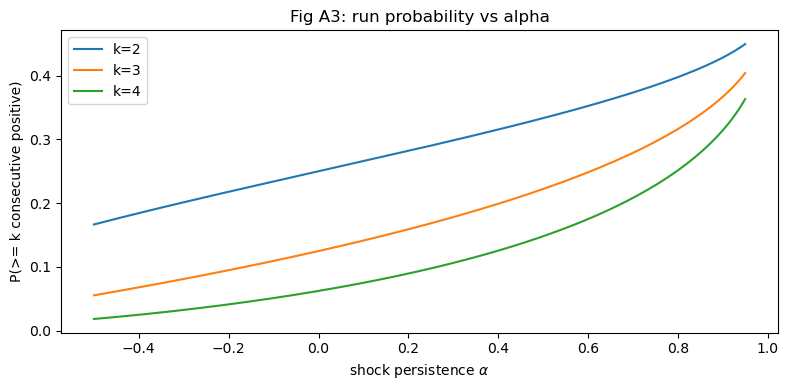

In [5]:
a = np.linspace(-0.5, 0.95, 200)
fig, ax = plt.subplots(figsize=(8,4))
for k in (2,3,4):
    ax.plot(a, ap.run_probability(a, k), label=f"k={k}")
ax.set_xlabel(r"shock persistence $\alpha$"); ax.set_ylabel("P(>= k consecutive positive)")
ax.set_title("Fig A3: run probability vs alpha"); ax.legend()
fig.tight_layout(); fig.savefig(OUT/"figA3_run_prob.png", dpi=130); plt.show()

## Figure A4a — ISM by goods vs non-housing services

corr goods vs services: 0.477


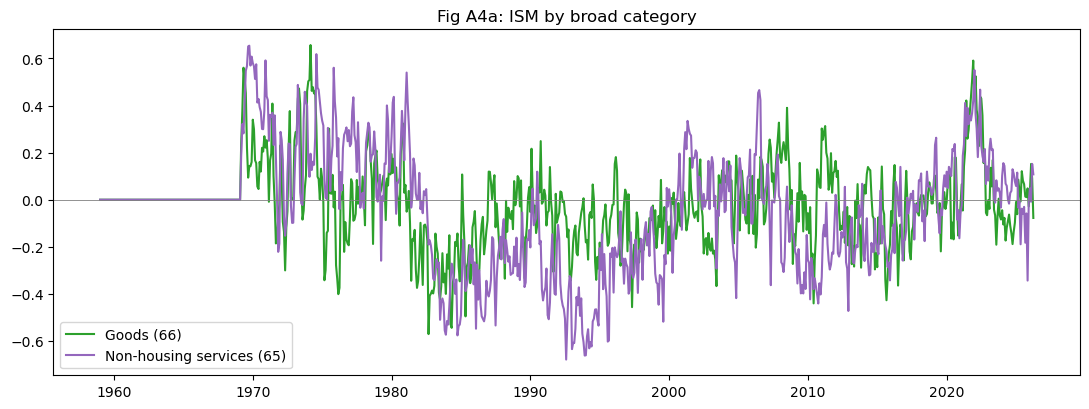

In [6]:
# Classify each category by its level-1 ancestor (Goods/Services) and whether under Housing,
# by walking the BEA interactive-table hierarchy.
import csv
rows=[]
with open(BEA/"T20404U_interactive.csv", newline="", encoding="utf-8-sig") as f:
    for r in csv.reader(f):
        if len(r)<2 or not str(r[0]).strip().lstrip("-").isdigit(): continue
        lab=r[1]; depth=len(lab)-len(lab.lstrip(" ")); rows.append((int(str(r[0]).strip()),depth,lab.strip()))
tree=pd.DataFrame(rows,columns=["line","depth","label"])
widths=sorted(tree["depth"].unique()); d2l={w:i+1 for i,w in enumerate(widths)}
tree["level"]=tree["depth"].map(d2l)
group=None; housing=False; g=[]; h=[]
for _,row in tree.iterrows():
    if row["level"]==1: group=row["label"]; housing=False
    if row["level"]==2 and "housing" in row["label"].lower(): housing=True
    elif row["level"]==2: housing=False
    g.append(group); h.append(housing)
tree["group"]=g; tree["is_housing"]=h
line2code=price.dropna(subset=["LineNumber"]).assign(LineNumber=lambda d:pd.to_numeric(d["LineNumber"],errors="coerce")).drop_duplicates("LineNumber").set_index("LineNumber")["SeriesCode"]
tree["key"]=tree["line"].map(line2code).map(lambda c:_nk(c) if pd.notna(c) else None)
goods_keys=[k for k in tree.loc[tree["group"].str.lower().eq("goods"),"key"] if k in keys]
svc_keys =[k for k in tree.loc[tree["group"].str.lower().eq("services") & ~tree["is_housing"],"key"] if k in keys]

def subset_ism(sub):
    sub=[k for k in sub if k in resid[1].columns]
    mp,mn=momentum_signals(resid[1][sub], ISMConfig(run_length=3))
    sp,sn=expenditure_weighted_shares(mp,mn,weights[sub]); return ism_index(sp,sn)
ism_goods=subset_ism(goods_keys); ism_svc=subset_ism(svc_keys)
fig,ax=plt.subplots(figsize=(11,4.2))
ax.plot(ism_goods.index, ism_goods, label=f"Goods ({len(goods_keys)})", color="tab:green")
ax.plot(ism_svc.index, ism_svc, label=f"Non-housing services ({len(svc_keys)})", color="tab:purple")
ax.axhline(0,color="grey",lw=.6); ax.legend(); ax.set_title("Fig A4a: ISM by broad category")
print("corr goods vs services:", round(ism_goods.corr(ism_svc),3))
fig.tight_layout(); fig.savefig(OUT/"figA4a_goods_services.png", dpi=130); plt.show()

## Figure A4b — ISM by AR(1) / AR(3) / AR(12)

corr AR1-AR3: 0.911 | AR1-AR12: 0.744


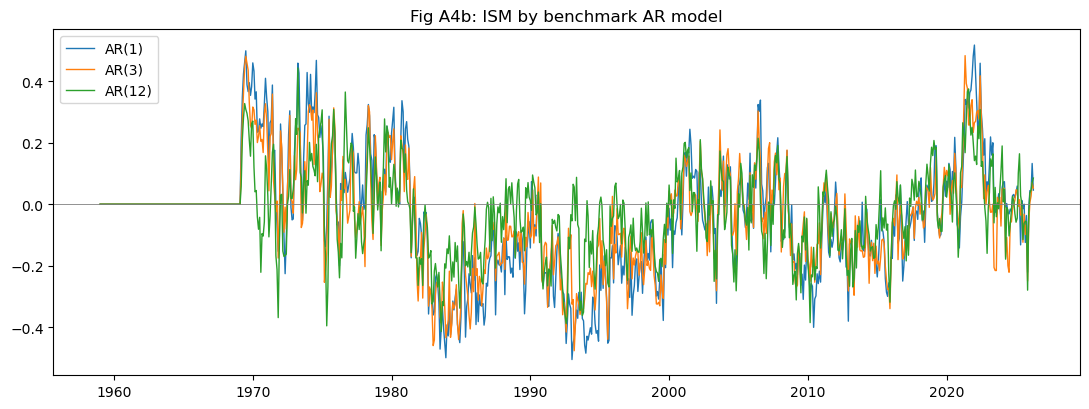

In [7]:
ism_ar={p: ism_variant(p,3)[0] for p in (1,3,12)}
fig,ax=plt.subplots(figsize=(11,4.2))
for p,c in zip((1,3,12),("tab:blue","tab:orange","tab:green")):
    ax.plot(ism_ar[p].index, ism_ar[p], lw=1.0, label=f"AR({p})", color=c)
ax.axhline(0,color="grey",lw=.6); ax.legend(); ax.set_title("Fig A4b: ISM by benchmark AR model")
print("corr AR1-AR3:", round(ism_ar[1].corr(ism_ar[3]),3), "| AR1-AR12:", round(ism_ar[1].corr(ism_ar[12]),3))
fig.tight_layout(); fig.savefig(OUT/"figA4b_ar_models.png", dpi=130); plt.show()

## Figure A5 / Table A5 — aggregate-data ISM vs category-level

corr: 0.511 (paper ~0.51)


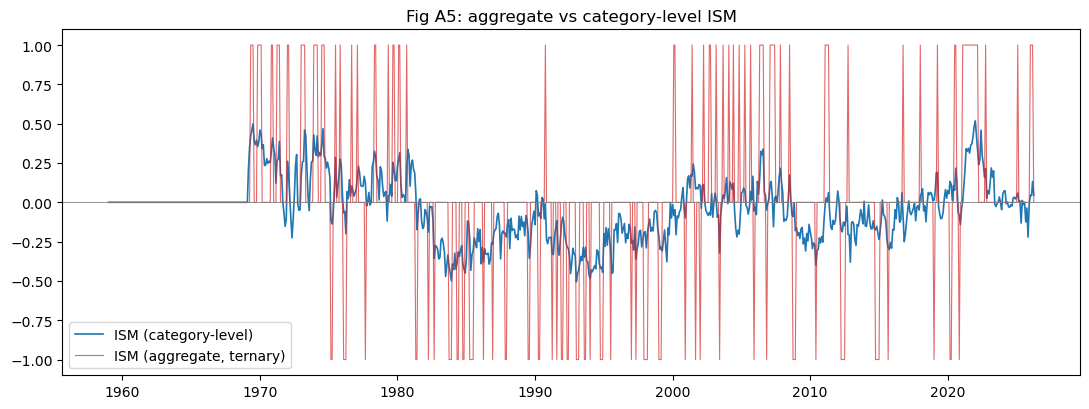

Table A5 (aggregate-ISM in-sample):


,horizon,col,spec,pce_yoy,ISM,S_pos,S_neg,R2,adjR2,N
0,12,1,none,0.775 (0.028),,,,0.604,0.603,784
1,12,2,components,0.758 (0.029),,0.534 (0.227),-0.120 (0.135),0.610,0.608,784
2,12,3,ism,0.762 (0.028),0.334 (0.128),,,0.608,0.607,784
3,12,4,none+controls,0.585 (0.086),,,,0.612,0.599,274
4,12,5,components+controls,0.572 (0.086),,0.458 (0.204),-0.009 (0.222),0.622,0.606,274
5,12,6,ism+controls,0.587 (0.087),0.298 (0.156),,,0.618,0.604,274
6,24,1,none,0.573 (0.033),,,,0.335,0.334,772
7,24,2,components,0.570 (0.035),,0.059 (0.277),-0.146 (0.168),0.335,0.333,772
8,24,3,ism,0.569 (0.034),0.101 (0.155),,,0.335,0.333,772
9,24,4,none+controls,0.167 (0.085),,,,0.452,0.433,274


In [8]:
agg = ap.aggregate_ism(agg_infl, ISMConfig(window=120, run_length=3))
fig,ax=plt.subplots(figsize=(11,4.2))
ax.plot(ism_b.index, ism_b, label="ISM (category-level)", color="tab:blue", lw=1.2)
ax.plot(agg.index, agg["ISM_agg"], label="ISM (aggregate, ternary)", color="tab:red", lw=.8, alpha=.7)
ax.axhline(0,color="grey",lw=.6); ax.legend(); ax.set_title("Fig A5: aggregate vs category-level ISM")
print("corr:", round(ism_b.corr(agg["ISM_agg"]),3), "(paper ~0.51)")
fig.tight_layout(); fig.savefig(OUT/"figA5_agg_vs_cat.png", dpi=130); plt.show()
# Table A5: in-sample forecast with the aggregate ISM
print("Table A5 (aggregate-ISM in-sample):")
forecasting.table1(pce_yoy, agg["ISM_agg"].rename("ISM"), agg["M_pos"].rename("S_pos"),
                   agg["M_neg"].rename("S_neg"), controls=controls, horizons=(12,24))

## Table A1 — in-sample fit across AR(1/3/12) x k(2/3/4) (with controls)

In [9]:
rowsA1=[]
for k in (2,3,4):
    for ar in (1,3,12):
        ism_v,_,_ = ism_variant(ar,k)
        for h in (12,24,36):
            r = forecasting.in_sample_regression(pce_yoy, ism_v, h, momentum="ism",
                                                 controls=controls, use_controls=True)
            rowsA1.append({"k":k,"AR":ar,"h":h,"ISM":r.coef_with_se("ISM"),
                           "adjR2":round(r.rsquared_adj,3),"N":r.nobs})
tableA1 = pd.DataFrame(rowsA1); tableA1

,k,AR,h,ISM,adjR2,N
0,2,1,12,0.773 (0.327),0.604,274
1,2,1,24,0.353 (0.436),0.432,274
2,2,1,36,0.021 (0.587),0.291,269
3,2,3,12,1.487 (0.370),0.619,274
4,2,3,24,0.824 (0.482),0.438,274
5,2,3,36,0.167 (0.583),0.291,269
6,2,12,12,0.143 (0.402),0.598,274
7,2,12,24,0.314 (0.445),0.432,274
8,2,12,36,0.158 (0.585),0.291,269
9,3,1,12,0.636 (0.486),0.600,274


## Tables A3 / A4 — momentum weighted by shock size and by 1/(1-rho)

In [10]:
wA3 = ap.compute_ism_weighted(infl, weights, ISMConfig(), scheme="size")
wA4 = ap.compute_ism_weighted(infl, weights, ISMConfig(), scheme="stickiness")
def insample_grid(ismv, spv, snv, tag):
    rows=[]
    for h in (12,24):
        for mom in ("components","ism"):
            r=forecasting.in_sample_regression(pce_yoy, ismv, h, momentum=mom,
                 s_pos=spv, s_neg=snv, controls=controls, use_controls=True)
            rows.append({"weighting":tag,"h":h,"spec":mom,"ISM":r.coef_with_se("ISM"),
                         "S_pos":r.coef_with_se("S_pos"),"S_neg":r.coef_with_se("S_neg"),
                         "adjR2":round(r.rsquared_adj,3),"N":r.nobs})
    return rows
tA34 = pd.DataFrame(insample_grid(wA3["ISM"],wA3["S_pos"],wA3["S_neg"],"size (A3)") +
                    insample_grid(wA4["ISM"],wA4["S_pos"],wA4["S_neg"],"stickiness (A4)"))
tA34

,weighting,h,spec,ISM,S_pos,S_neg,adjR2,N
0,size (A3),12,components,,1.968 (0.828),0.324 (0.494),0.630,274
1,size (A3),12,ism,1.096 (0.509),,,0.610,274
2,size (A3),24,components,,0.801 (0.490),0.306 (0.465),0.436,274
3,size (A3),24,ism,0.380 (0.362),,,0.432,274
4,stickiness (A4),12,components,,0.575 (0.305),0.676 (0.359),0.605,274
5,stickiness (A4),12,ism,0.121 (0.212),,,0.598,274
6,stickiness (A4),24,components,,0.239 (0.366),0.412 (0.410),0.431,274
7,stickiness (A4),24,ism,0.003 (0.281),,,0.431,274


## Table A6 — parametric alpha-hat measure (aggregate)

In [11]:
alpha_hat = ap.rolling_rho_alpha(agg_infl, window=120)["alpha_hat"].rename("ISM")  # use as the "momentum" regressor
print("Table A6 (parametric alpha-hat in place of ISM): note the paper finds a perverse (negative) sign")
forecasting.table1(pce_yoy, alpha_hat, alpha_hat.rename("S_pos"), alpha_hat.rename("S_neg"),
                   controls=controls, horizons=(12,24))

Table A6 (parametric alpha-hat in place of ISM): note the paper finds a perverse (negative) sign


,horizon,col,spec,pce_yoy,ISM,S_pos,S_neg,R2,adjR2,N
0,12,1,none,0.775 (0.028),,,,0.604,0.603,784
1,12,2,components,0.498 (0.045),,-3.928 (0.531),-3.928 (0.531),0.637,0.635,676
2,12,3,ism,0.498 (0.045),-7.855 (1.062),,,0.637,0.635,676
3,12,4,none+controls,0.585 (0.086),,,,0.612,0.599,274
4,12,5,components+controls,0.664 (0.096),,3.788 (1.177),3.788 (1.177),0.630,0.616,274
5,12,6,ism+controls,0.664 (0.096),7.577 (2.353),,,0.630,0.616,274
6,24,1,none,0.573 (0.033),,,,0.335,0.334,772
7,24,2,components,0.003 (0.046),,-8.136 (0.567),-8.136 (0.567),0.522,0.520,664
8,24,3,ism,0.003 (0.046),-16.273 (1.133),,,0.522,0.520,664
9,24,4,none+controls,0.167 (0.085),,,,0.452,0.433,274


## Figures A6 / A7 / A8 — IRF robustness (heavy)

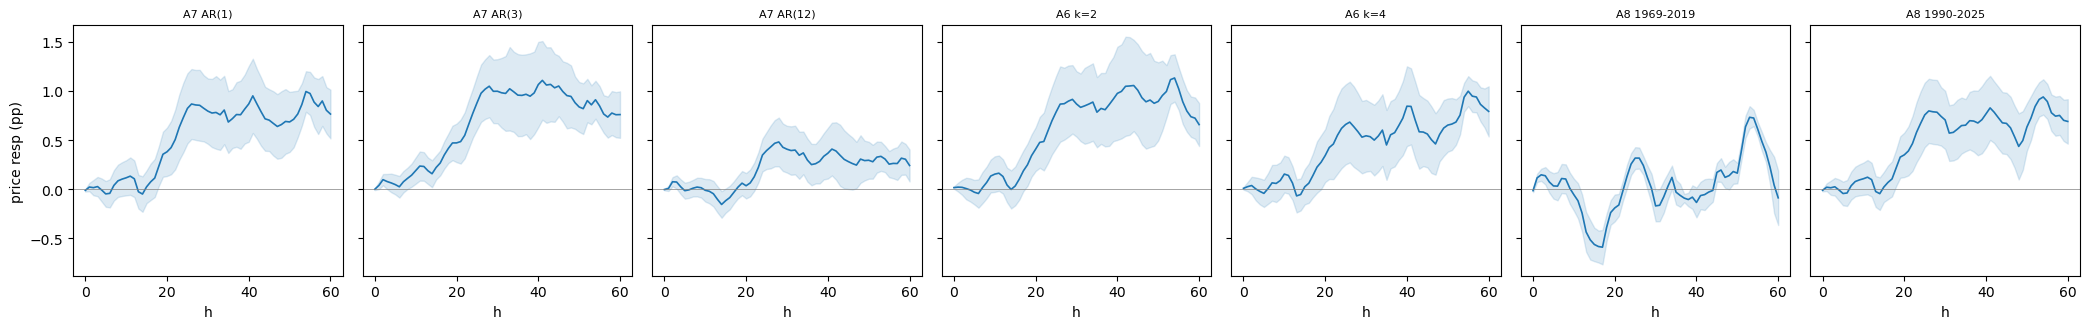

In [12]:
# A7: IRF by AR model (k=3). A6: by k (AR1). A8: by subsample (AR1,k3).
ctrl_lp = controls.drop(columns=["pce_yoy"], errors="ignore")
H=range(0,61)
def irf(ismv, sub=None):
    p = pcepi if sub is None else pcepi.loc[sub[0]:sub[1]]
    iv = ismv if sub is None else ismv.loc[sub[0]:sub[1]]
    cc = ctrl_lp if sub is None else ctrl_lp.loc[sub[0]:sub[1]]
    return irf_price_to_ism(p, iv, cc, horizons=H)

figs = {
  "A7 AR(1)": irf(ism_ar[1]), "A7 AR(3)": irf(ism_ar[3]), "A7 AR(12)": irf(ism_ar[12]),
  "A6 k=2": irf(ism_variant(1,2)[0]), "A6 k=4": irf(ism_variant(1,4)[0]),
  "A8 1969-2019": irf(ism_b, ("1969","2019")), "A8 1990-2025": irf(ism_b, ("1990","2025")),
}
fig, axes = plt.subplots(1, len(figs), figsize=(3.0*len(figs), 3.4), sharey=True)
for ax,(t,d) in zip(axes, figs.items()):
    ax.plot(d["h"], d["beta"], color="tab:blue", lw=1.2)
    ax.fill_between(d["h"], d["lo_90"], d["hi_90"], color="tab:blue", alpha=.15)
    ax.axhline(0,color="grey",lw=.5); ax.set_title(t, fontsize=8); ax.set_xlabel("h")
axes[0].set_ylabel("price resp (pp)")
fig.tight_layout(); fig.savefig(OUT/"figA6A7A8_irf_robustness.png", dpi=130); plt.show()

## Table A2 — out-of-sample LASSO using the AR(3) ISM (heavy)

In [13]:
ism_ar3 = ism_ar[3]
tableA2 = oos_lasso.table2(pce_yoy, ism_ar3, controls=None, horizons=(12,24,36),
                           lam_grid=np.logspace(-3,0,8), window=120)
print("Table A2 (AR(3) momentum, baseline model):"); tableA2

Table A2 (AR(3) momentum, baseline model):


,h,rmsfe_base,rmsfe_ism,rmsfe_ratio,GW_F,GW_p,lam_base,lam_ism
0,12,1.4498,1.3311,0.9181,8.49,0.0036,0.001000,0.001000
1,24,1.8498,1.7078,0.9232,6.02,0.0142,0.051795,0.007197
2,36,1.8504,1.7459,0.9436,3.77,0.0523,0.138950,0.007197


## Notes
All exhibits use the pinned 130-category set and the tested modules. See
`docs/methodology.md` and `docs/DECISIONS.md`. Heavy cells (A1b, A6/A7/A8, A2,
A1) build multiple full-history ISM variants and may take several minutes.